In [43]:
import glob, os
import time
import numpy as np
from scipy import ndimage
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
in_dir = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/20181204/gefs18/run/merged/'
in_basename = 'corlasso_sub_cloudOnHamsl.M1.m1.'
ensmember = 'gefs18'
out_dir = in_dir
out_basename = 'reg_refl_'

in_files = sorted(glob.glob(f'{in_dir}{in_basename}{ensmember}*d4.nc'))

In [3]:
in_files[100]

'/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/20181204/gefs18/run/merged/corlasso_sub_cloudOnHamsl.M1.m1.gefs18_2018120400_f202000_d4.nc'

In [56]:
ds = xr.open_dataset(in_files[100])
in_time = ds['Time']
XLONG = ds['XLONG']
XLAT = ds['XLAT']
REFL_10CM = ds['REFL_10CM'].squeeze()
REFL_10CM_MAX = ds['REFL_10CM_MAX'].squeeze()

In [5]:
REFL_10CM_MAX

<xarray.DataArray 'REFL_10CM_MAX' (south_north: 2775, west_east: 2145)>
[5952375 values with dtype=float32]
Coordinates:
    Time     datetime64[ns] 2018-12-04T20:20:00
    XLONG    (south_north, west_east) float32 ...
    XLAT     (south_north, west_east) float32 ...
    XTIME    float32 ...
Dimensions without coordinates: south_north, west_east
Attributes:
    description:  column-maximum radar reflectivity (lambda = 10 cm)
    units:        dBZ
    stagger:

In [23]:
# REFL_10CM.sel(HAMSL=1000).plot()

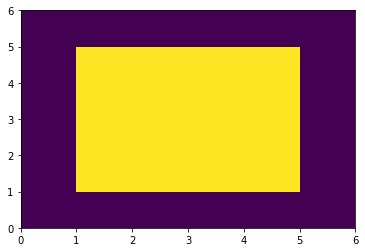

In [27]:
# Make a kernel for weights
ratio = 5   # Must be odd number
start_idx = int((ratio-1) / 2)
kernel = np.zeros((ratio+1,ratio+1), dtype=int)
kernel[1:ratio, 1:ratio] = 1
plt.pcolormesh(kernel)

In [8]:
def convolve_reflectivity(in_reflectivity, kernel):
    # Convert reflectivity to linear unit
    linrefl = 10. ** (in_reflectivity / 10.)
    # Make an array for counting number of grids for convolution
    mask_goodvalues = (~np.isnan(in_reflectivity)).astype(float)

    # Apply convolution filter
    bkg_linrefl = ndimage.convolve(linrefl, kernel, mode='constant', cval=0.0)
    numPixs = ndimage.convolve(mask_goodvalues, kernel, mode='constant', cval=0.0)
    # Mask missing data area
    bkg_linrefl[mask_goodvalues==0] = 0
    numPixs[mask_goodvalues==0] = 0

    # Calculate average linear reflectivity and convert to log values
    out_reflectivity = np.full(in_reflectivity.shape, np.NaN, dtype=np.float32)
    out_reflectivity[numPixs>0] = 10.0 * np.log10(bkg_linrefl[numPixs>0] / numPixs[numPixs>0])

    # Remove pixels with 0 number of pixels
    out_reflectivity[mask_goodvalues==0] = np.NaN
    
    return out_reflectivity

In [9]:
# Make a 3D kernel
kernel3d = kernel[None,:,:]
# Call convlution function
REFL_10CM_conv = convolve_reflectivity(REFL_10CM.data, kernel3d)
REFL_10CM_MAX_conv = convolve_reflectivity(REFL_10CM_MAX.data, kernel)

In [28]:
# Subsample every X grid points
REFL_10CM_reg = REFL_10CM_conv[:,start_idx::ratio,start_idx::ratio]
REFL_10CM_MAX_reg = REFL_10CM_MAX_conv[start_idx::ratio,start_idx::ratio]
XLONG_reg = XLONG.data[start_idx::ratio,start_idx::ratio]
XLAT_reg = XLAT.data[start_idx::ratio,start_idx::ratio]
REFL_10CM_reg.shape, REFL_10CM_MAX_reg.shape

((29, 555, 429), (555, 429))

In [64]:
ds.attrs['DX'] * ratio

500.0

In [13]:
nleadingchar = len(f'{in_basename}{ensmember}_')
fname = os.path.basename(in_files[100])
ftimestr = fname[nleadingchar:]
out_filename = f'{out_dir}{out_basename}{ftimestr}'
out_filename

'/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/20181204/gefs18/run/merged/reg_refl_2018120400_f202000_d4.nc'

In [16]:
Time

<xarray.DataArray 'Time' (Time: 1)>
array(['2018-12-04T20:20:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * Time     (Time) datetime64[ns] 2018-12-04T20:20:00
    XTIME    (Time) float32 860.0

In [34]:
nz, ny, nx = REFL_10CM_reg.shape
# Create a coordinate to mimic subsampling ratio of the full coordinate
xcoord = (np.linspace(2, nx*ratio+2, nx, endpoint=False, dtype=int))
ycoord = (np.linspace(2, ny*ratio+2, ny, endpoint=False, dtype=int))
print(len(xcoord), len(ycoord))
print(xcoord[0:10], xcoord[-10:])
print(ycoord[0:10], ycoord[-10:])

429 555
[ 2  7 12 17 22 27 32 37 42 47] [2097 2102 2107 2112 2117 2122 2127 2132 2137 2142]
[ 2  7 12 17 22 27 32 37 42 47] [2727 2732 2737 2742 2747 2752 2757 2762 2767 2772]


In [51]:
REFL_10CM.attrs, REFL_10CM_MAX.attrs

({'units': 'dBZ', 'stagger': ''},
 {'description': 'column-maximum radar reflectivity (lambda = 10 cm)',
  'units': 'dBZ',
  'stagger': ''})

In [53]:
# Define output variables
var_dict = {
    'REFL_10CM': (['Time', 'HAMSL', 'south_north', 'west_east'], np.expand_dims(REFL_10CM_reg, axis=0), REFL_10CM.attrs),
    'REFL_10CM_MAX': (['Time', 'south_north', 'west_east'], np.expand_dims(REFL_10CM_MAX_reg, axis=0), REFL_10CM_MAX.attrs),
}
# Output coordinates
coord_dict = {
    'Time': (['Time'], in_time.data),
    'HAMSL': (['HAMSL'], ds['HAMSL'].data, ds.HAMSL.attrs),
    'south_north': (['south_north'], ycoord),
    'west_east': (['west_east'], xcoord),
}
# Output global attributes
gattr_dict = {
    'Title': 'Regrid reflectivity from LASSO',
    'SIMULATION_START_DATE': ds.attrs['SIMULATION_START_DATE'],
    'run_name': ds.attrs['run_name'],
    'Contact': 'Zhe Feng, zhe.feng@pnnl.gov',
    'Institution': 'Pacific Northwest National Laboratory',
    'Created_on': time.ctime(time.time()),
}
# Define xarray dataset
ds_out = xr.Dataset(var_dict, coords=coord_dict, attrs=gattr_dict)

# Set encoding/compression for all variables
comp = dict(zlib=True)
encoding = {var: comp for var in ds_out.data_vars}

# Write to netcdf file
ds_out.to_netcdf(
    path=out_filename, mode='w', format='NETCDF4', unlimited_dims='time', encoding=encoding,
)

In [55]:
ds_out.west_east.attrs

{}

In [38]:
ds.attrs

{'DX': 100.0,
 'DY': 100.0,
 'SIMULATION_START_DATE': '2018-12-04_06:00:00',
 'WEST-EAST_GRID_DIMENSION': 2146,
 'SOUTH-NORTH_GRID_DIMENSION': 2776,
 'BOTTOM-TOP_GRID_DIMENSION': 150,
 'GRIDTYPE': 'C',
 'CEN_LAT': -32.015686,
 'CEN_LON': -64.24225,
 'TRUELAT1': -30.0,
 'TRUELAT2': -60.0,
 'MOAD_CEN_LAT': -32.500015,
 'STAND_LON': -64.728,
 'POLE_LAT': 90.0,
 'POLE_LON': 0.0,
 'MAP_PROJ': 1,
 'MAP_PROJ_CHAR': 'Lambert Conformal',
 'run_name': 'gefs18_20181204',
 'model_type': 'WRF',
 'model_version': 'NCAR V4.3.1 + LASSO modifications',
 'model_source_repository': 'https://code.arm.gov/lasso/lasso-cacti/lasso-wrf-cacti/',
 'model_source_git_hash': '3e761eac',
 'subset_source_repository': 'https://code.arm.gov/lasso/lasso-cacti/subsetwrf',
 'subset_source_git_hash': '290a2df',
 'domain_num': 4,
 'process_version': '?',
 'dod_version': '?',
 'input_source': '/gpfs/wolf/cli120/proj-shared/sey/cacti/wrf/prod//20181204_gefs_en18/run/merged',
 'site_id': 'cor',
 'platform_id': 'corlasso',
 'f

In [39]:
ds.attrs['SIMULATION_START_DATE']

'2018-12-04_06:00:00'

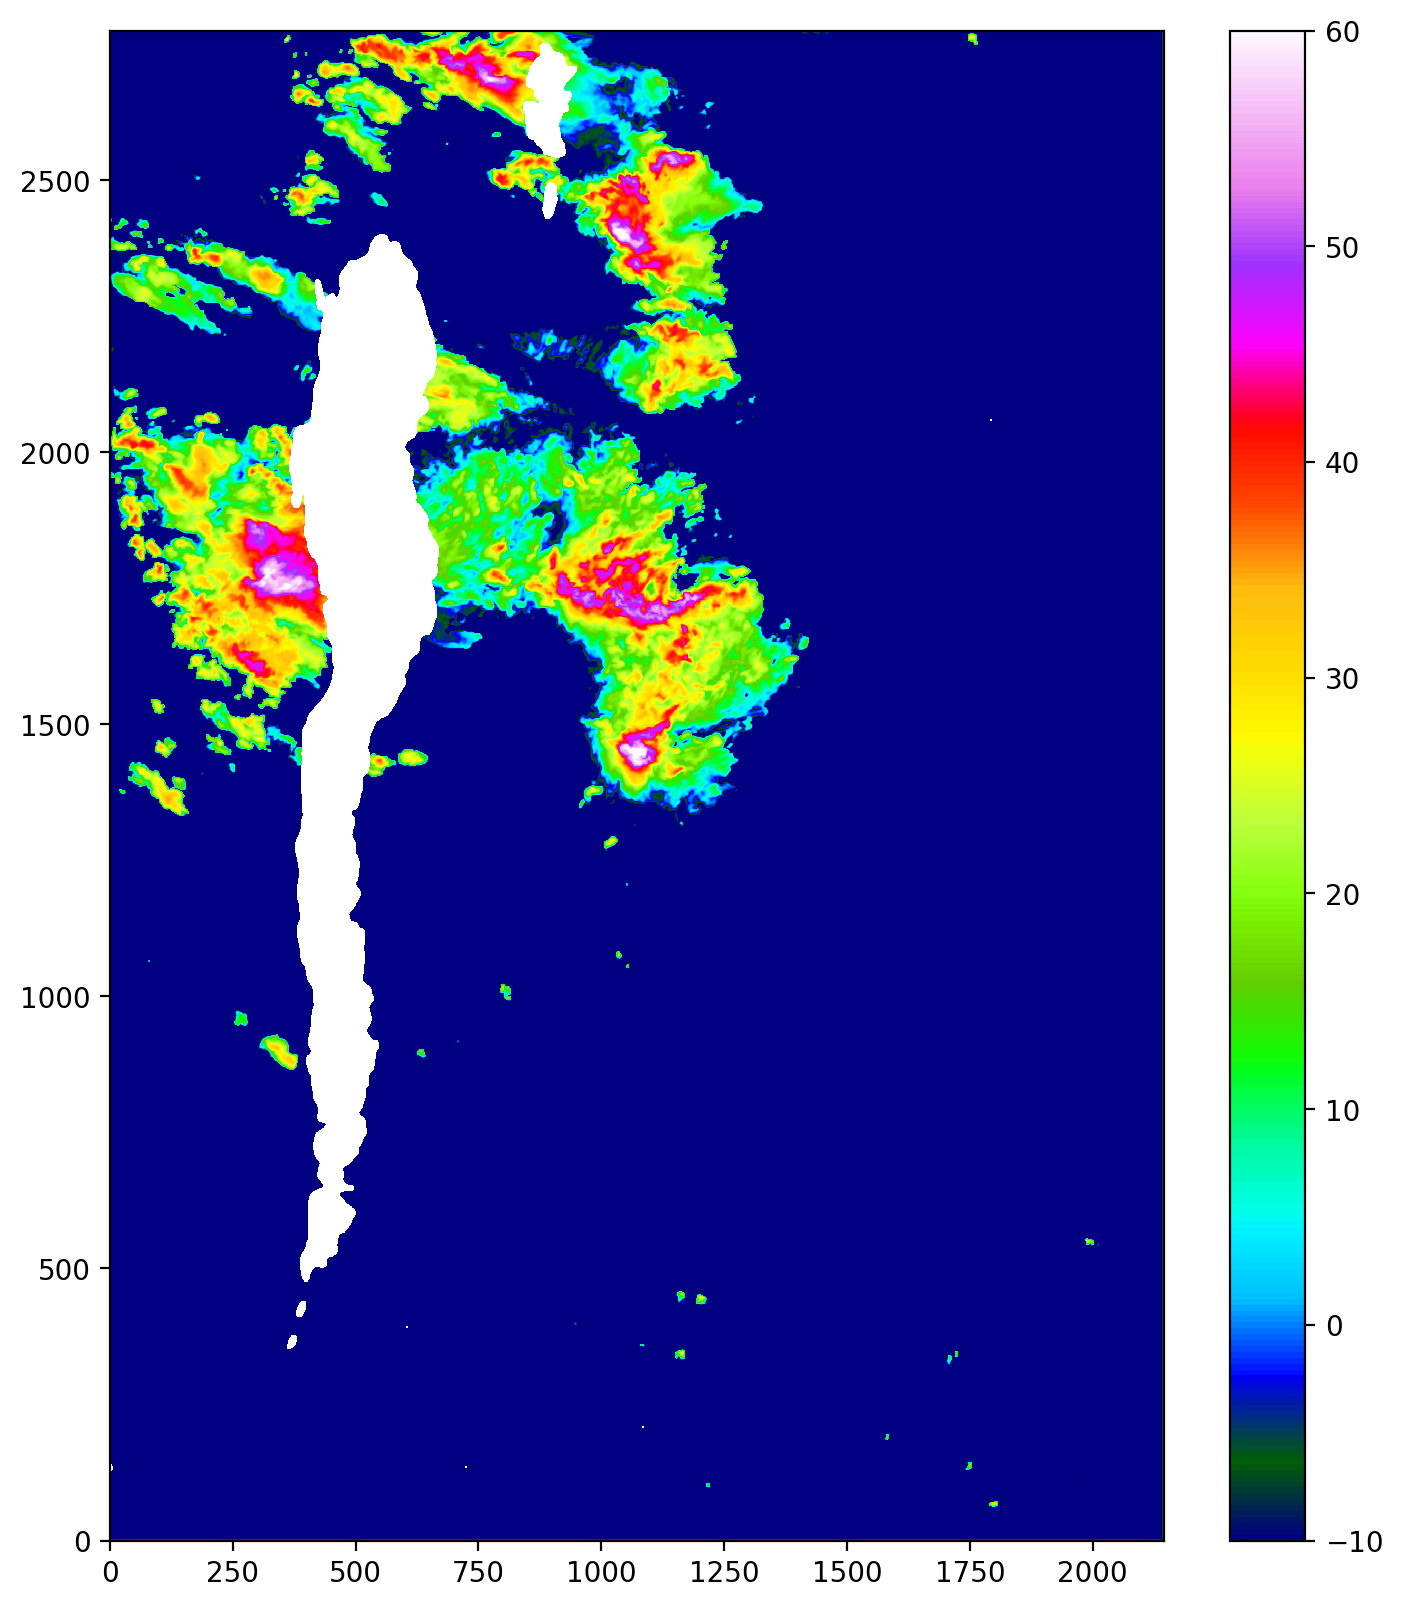

In [75]:
fig = plt.figure(figsize=[8.5,10], dpi=200)
plt.pcolormesh(REFL_10CM_conv[2,:,:], vmin=-10, vmax=60, cmap='gist_ncar')
plt.colorbar()

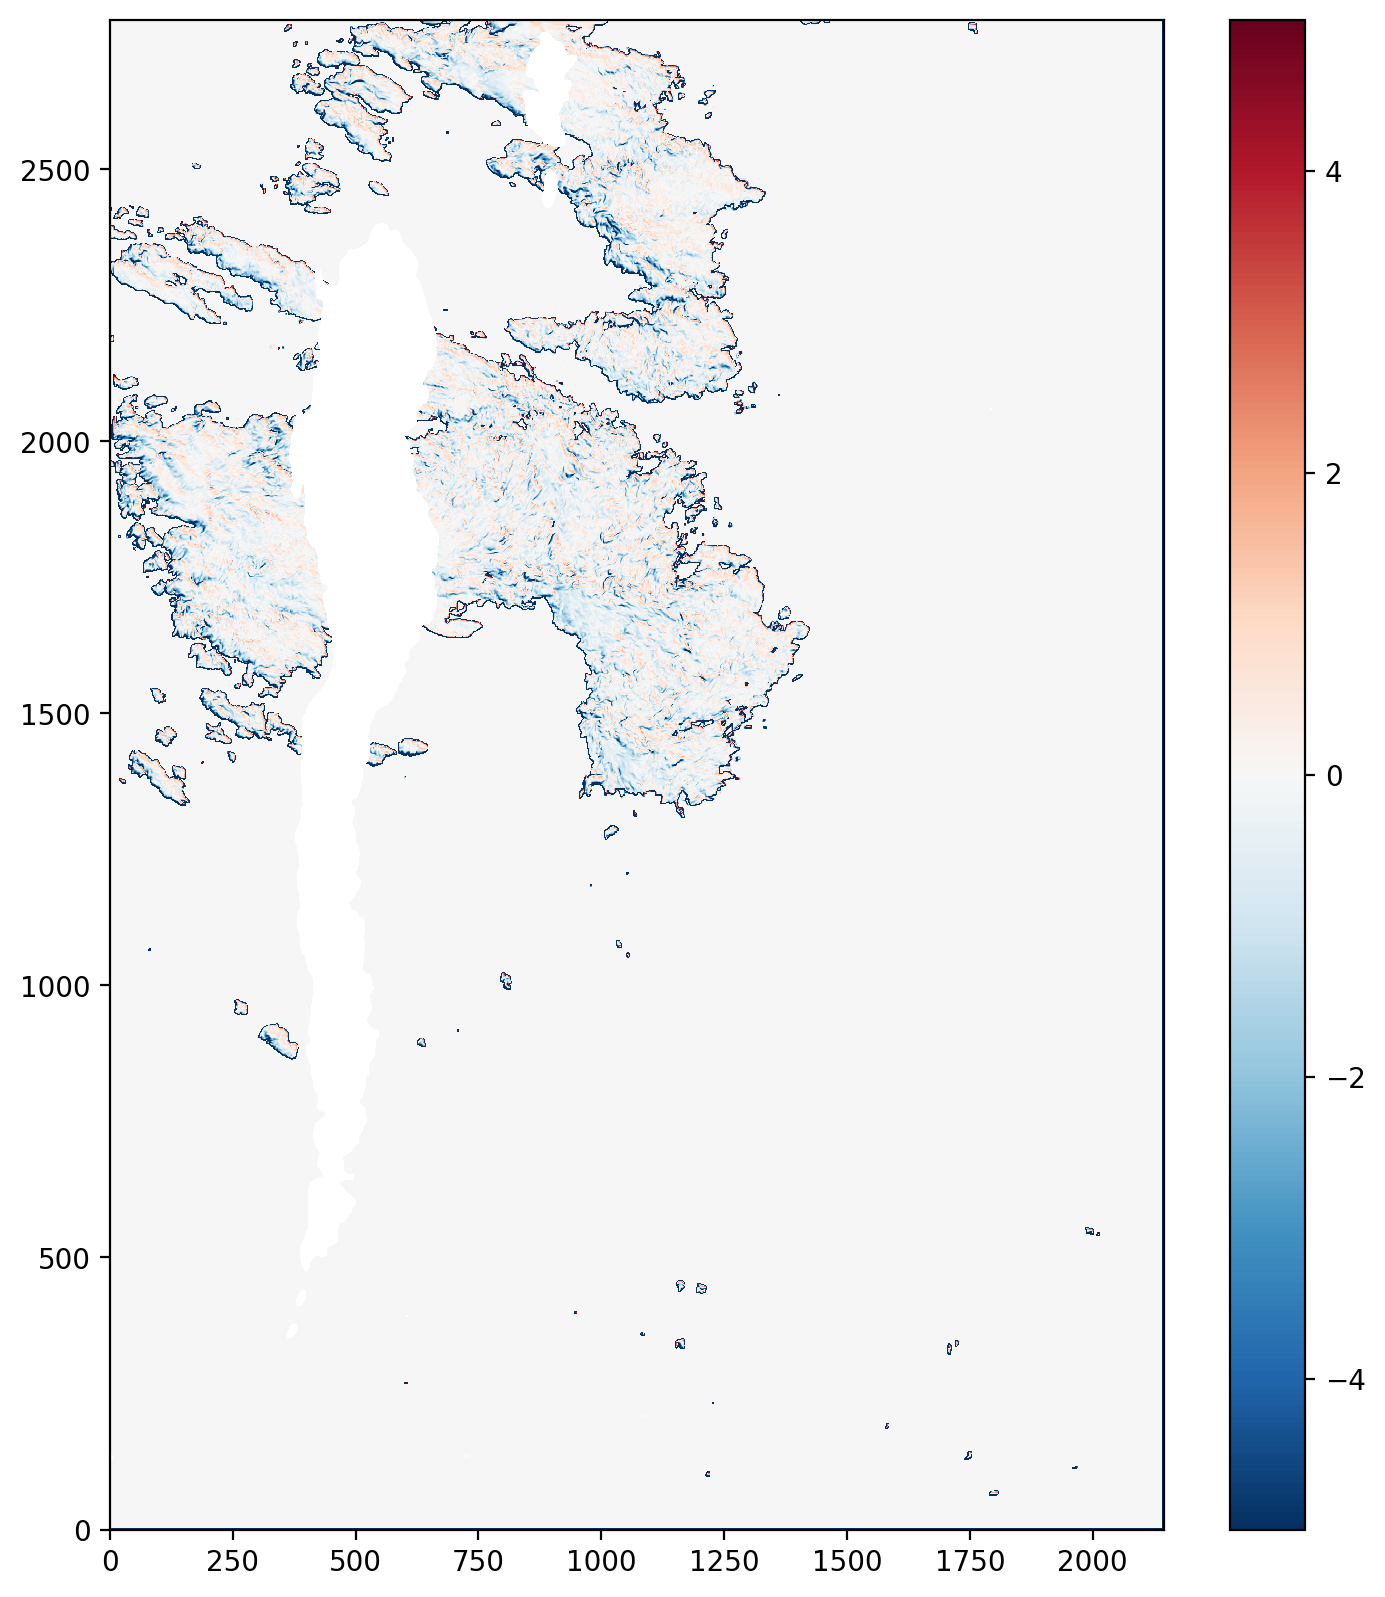

In [77]:
fig = plt.figure(figsize=[8.5,10], dpi=200)
diff = REFL_10CM[2,:,:].data - REFL_10CM_conv[2,:,:]
plt.pcolormesh(diff, vmin=-5, vmax=5, cmap='RdBu_r')
plt.colorbar()

(array([7.82435091e-03, 8.37256152e-03, 9.38223292e-03, 2.11922557e-02,
        1.08401117e-02, 2.31814770e-02, 1.70620008e-02, 1.20401507e-02,
        1.26473994e-02, 1.33920019e-02, 1.35401995e-02, 1.48595195e-02,
        1.61547424e-02, 1.69619976e-02, 1.78391345e-02, 1.95006344e-02,
        2.02283689e-02, 2.06066944e-02, 2.18838444e-02, 2.19440873e-02,
        2.27561619e-02, 2.32103936e-02, 2.37730625e-02, 2.40875306e-02,
        2.46779112e-02, 2.55008295e-02, 2.64960426e-02, 2.67105075e-02,
        2.64803795e-02, 2.57128846e-02, 2.58140927e-02, 2.40176488e-02,
        2.38766803e-02, 2.50875631e-02, 2.45995954e-02, 2.29983385e-02,
        2.08392321e-02, 2.00042652e-02, 1.95030441e-02, 1.85704836e-02,
        1.75270762e-02, 1.71222437e-02, 1.62294436e-02, 1.44257705e-02,
        1.31413913e-02, 1.26329411e-02, 1.17678527e-02, 1.06425149e-02,
        9.63766291e-03, 8.89547009e-03, 8.00387482e-03, 7.67494846e-03,
        7.25686257e-03, 6.73154428e-03, 6.18453853e-03, 5.631508

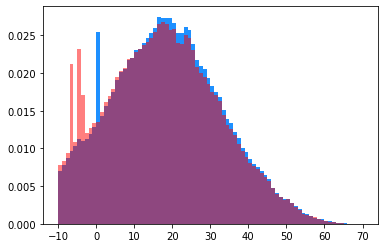

In [85]:
zbins = np.arange(-10, 70.1, 1)
# plt.hist(REFL_10CM_MAX.data.ravel(), bins=zbins, density=True)
plt.hist(REFL_10CM[2,:,:].data.ravel(), bins=zbins, density=True, color='dodgerblue')
plt.hist(REFL_10CM_conv[2,:,:].ravel(), bins=zbins, density=True, alpha=0.5, color='r')

In [90]:
REFL_10CM_conv.shape

(29, 2775, 2145)

In [91]:
REFL_10CM_conv[:,2::5,2::5].shape

(29, 555, 429)

In [67]:
# Convert to linear unit
linrefl = 10. ** (REFL_10CM / 10.)
# Make an array for counting number of grids for convolution
mask_goodvalues = (~np.isnan(REFL_10CM.data)).astype(float)

# Make a 3D kernel
kernel3d = kernel[None,:,:]
# Apply convolution filter
bkg_linrefl = ndimage.convolve(linrefl, kernel3d, mode='constant', cval=0.0)
numPixs = ndimage.convolve(mask_goodvalues, kernel3d, mode='constant', cval=0.0)
# Mask missing data area
bkg_linrefl[mask_goodvalues==0] = 0
numPixs[mask_goodvalues==0] = 0

# Calculate average linear reflectivity and convert to log values
refl_conv = np.full(REFL_10CM.shape, np.NaN, dtype=np.float32)
refl_conv[numPixs>0] = 10.0 * np.log10(bkg_linrefl[numPixs>0] / numPixs[numPixs>0])

# Remove pixels with 0 number of pixels
refl_conv[mask_goodvalues==0] = np.NaN

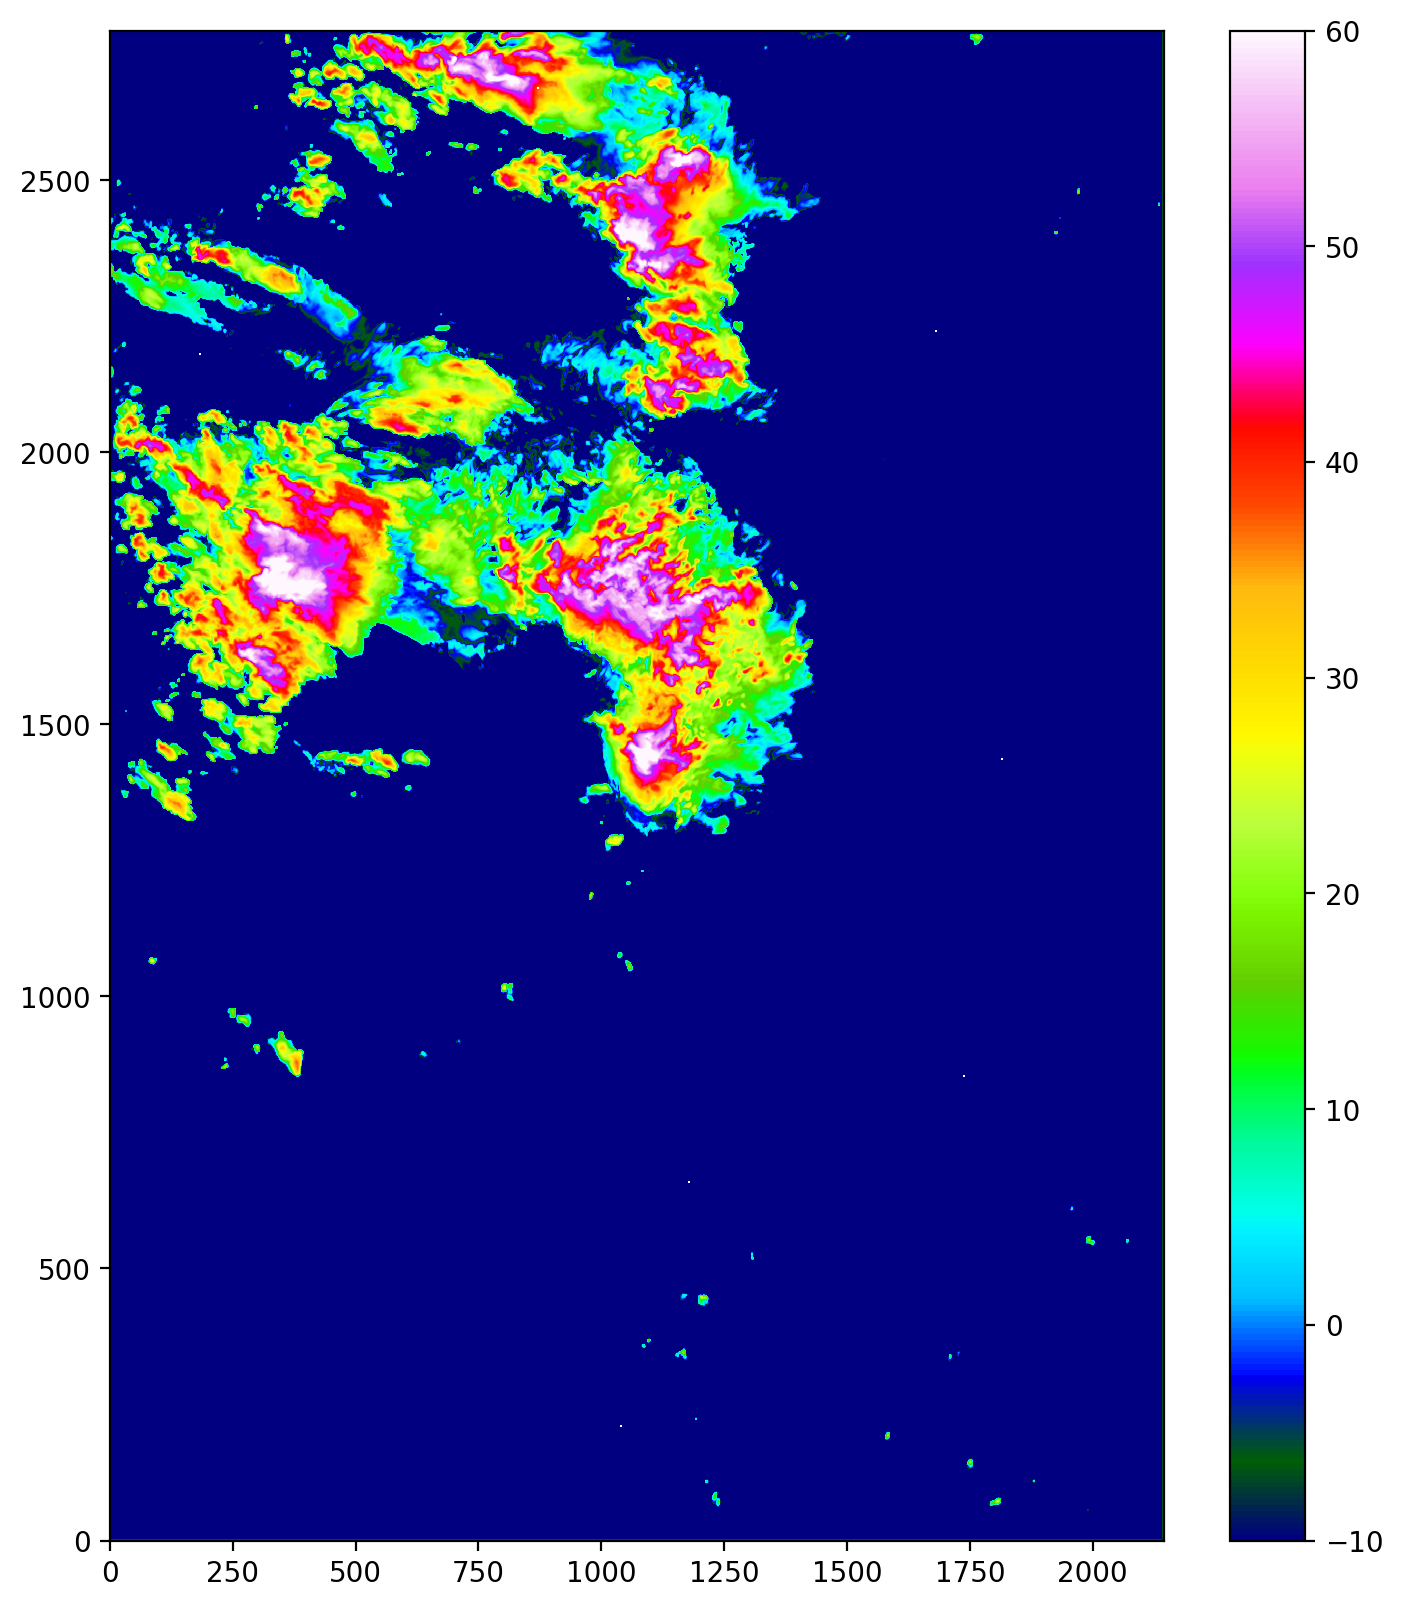

In [68]:
fig = plt.figure(figsize=[8.5,10], dpi=200)
plt.pcolormesh(refl_conv[5,:,:], vmin=-10, vmax=60, cmap='gist_ncar')
plt.colorbar()

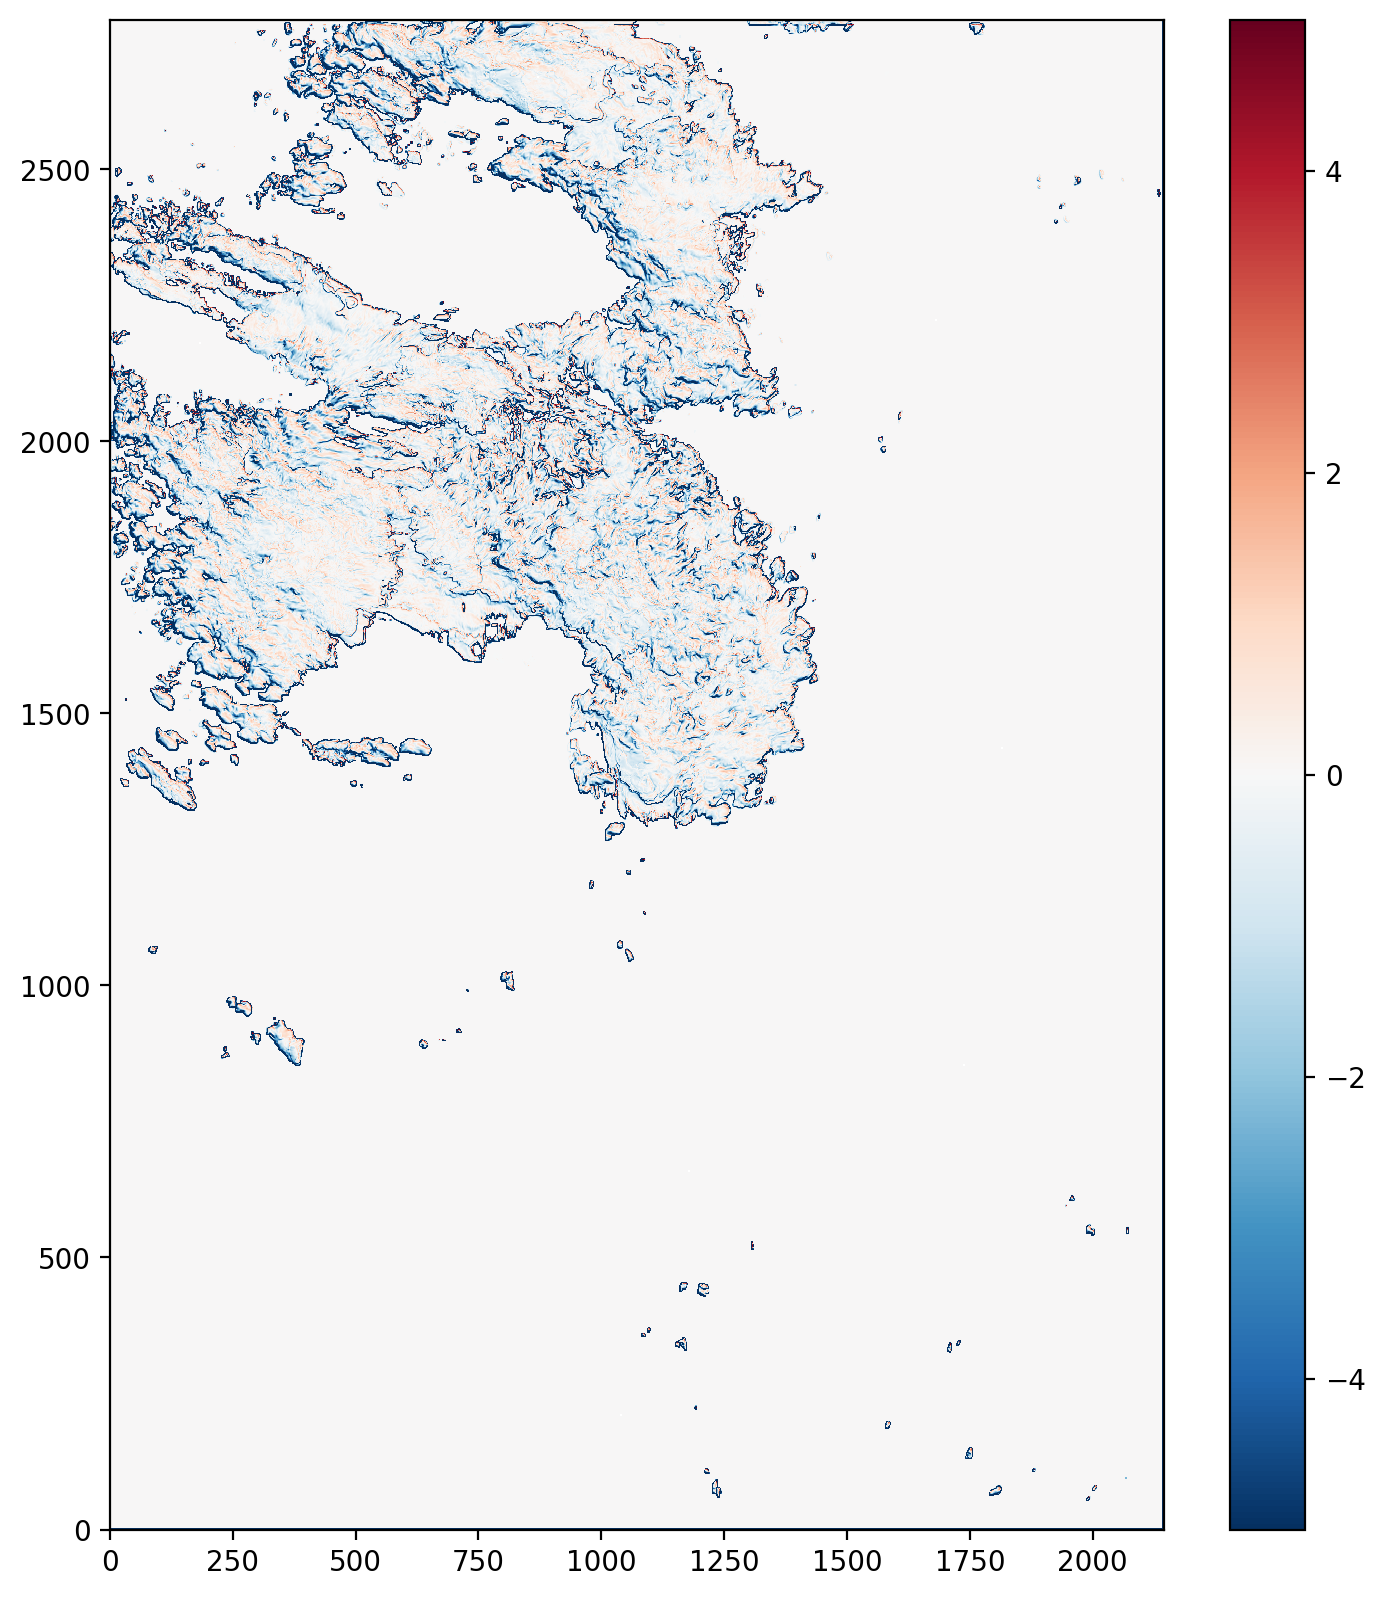

In [69]:
fig = plt.figure(figsize=[8.5,10], dpi=200)
diff = REFL_10CM[5,:,:].data - refl_conv[5,:,:]
plt.pcolormesh(diff, vmin=-5, vmax=5, cmap='RdBu_r')
plt.colorbar()

In [25]:
# Convert to linear unit
linrefl = 10. ** (REFL_10CM.sel(HAMSL=1000) / 10.)
# Make an array for counting number of grids for convolution
mask_goodvalues = np.ones(REFL_10CM_MAX.shape)
mask_goodvalues[np.isnan(REFL_10CM.sel(HAMSL=1000))] = 0

# Apply convolution filter 
bkg_linrefl = ndimage.convolve(linrefl, mask, mode='constant', cval=0.0)
numPixs = ndimage.convolve(mask_goodvalues, mask, mode='constant', cval=0.0)
bkg_linrefl[mask_goodvalues==0]=0
numPixs[mask_goodvalues==0]=0

# Calculate average linear reflectivity and convert to log values
refl_conv = np.full(REFL_10CM_MAX.shape, 0.0, dtype=np.float32)
refl_conv[numPixs>0] = 10.0 * np.log10(bkg_linrefl[numPixs>0] / numPixs[numPixs>0])

# Remove pixels with 0 number of pixels
refl_conv[mask_goodvalues==0] = np.nan

In [51]:
# mask.astype(float)

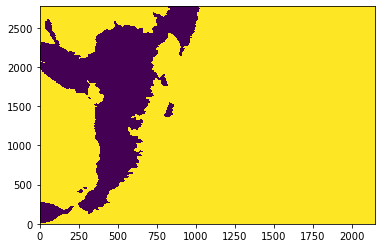

In [54]:
plt.pcolormesh(mask[1,:,:])

In [39]:
mask_goodvalues.shape, mask_goodvalues.dtype

((29, 2775, 2145), dtype('float64'))

In [35]:
np.isnan(REFL_10CM).shape

(29, 2775, 2145)

In [34]:
REFL_10CM.shape

(29, 2775, 2145)

In [27]:
# # Convert to linear unit
# linrefl = 10. ** (REFL_10CM_MAX / 10.)
# # Make an array for counting number of grids for convolution
# mask_goodvalues = np.ones(REFL_10CM_MAX.shape)

# # Apply convolution filter 
# bkg_linrefl = ndimage.convolve(linrefl, mask, mode='constant', cval=0.0)
# numPixs = ndimage.convolve(mask_goodvalues, mask, mode='constant', cval=0.0)
# # bkg_linrefl[mask_goodvalues==0]=0
# # numPixs[mask_goodvalues==0]=0

# # Calculate average linear reflectivity and convert to log values
# refl_conv = np.full(REFL_10CM_MAX.shape, 0.0, dtype=np.float32)
# refl_conv[numPixs>0] = 10.0 * np.log10(bkg_linrefl[numPixs>0] / numPixs[numPixs>0])

# # # Remove pixels with 0 number of pixels
# # refl_conv[mask_goodvalues==0] = np.nan

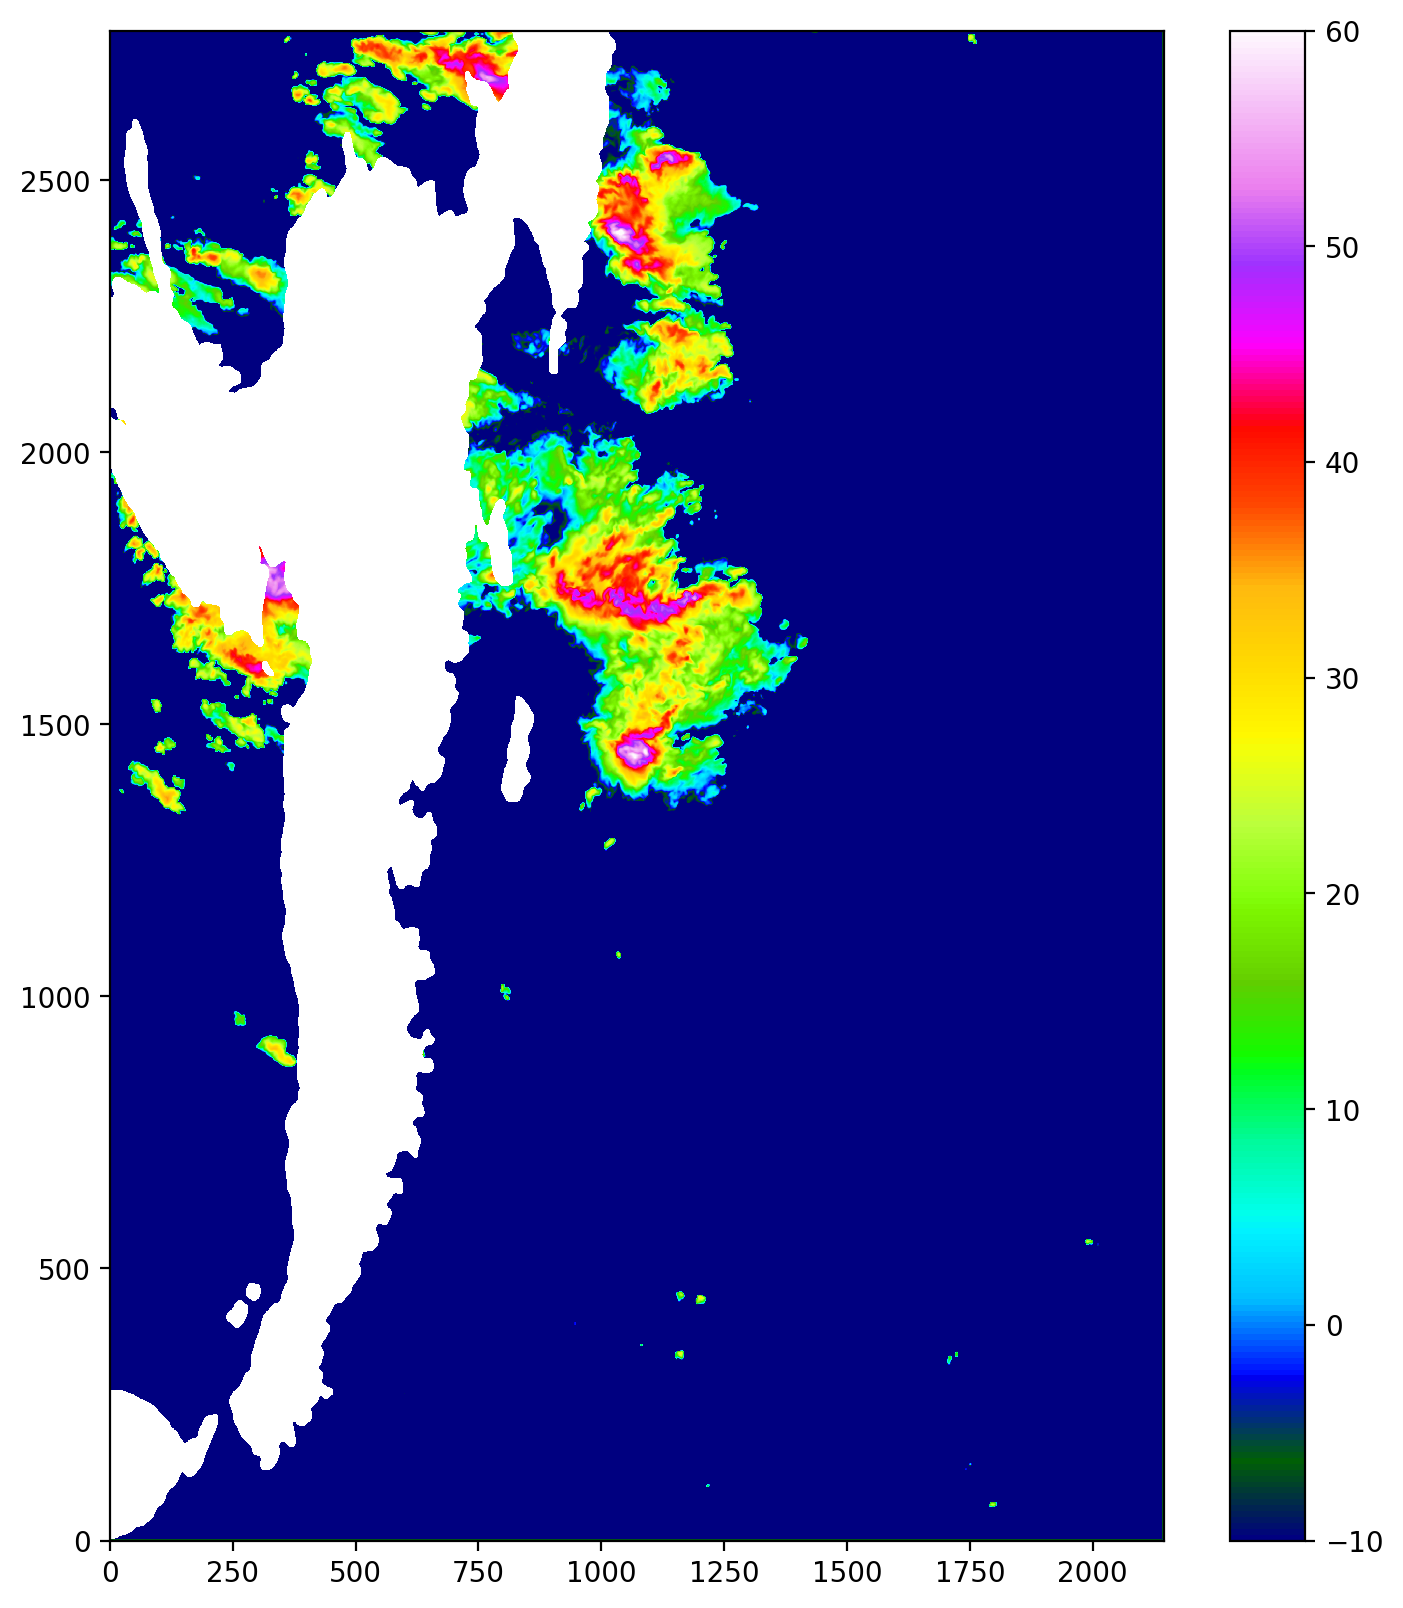

In [28]:
fig = plt.figure(figsize=[8.5,10], dpi=200)
plt.pcolormesh(refl_conv, vmin=-10, vmax=60, cmap='gist_ncar')
plt.colorbar()

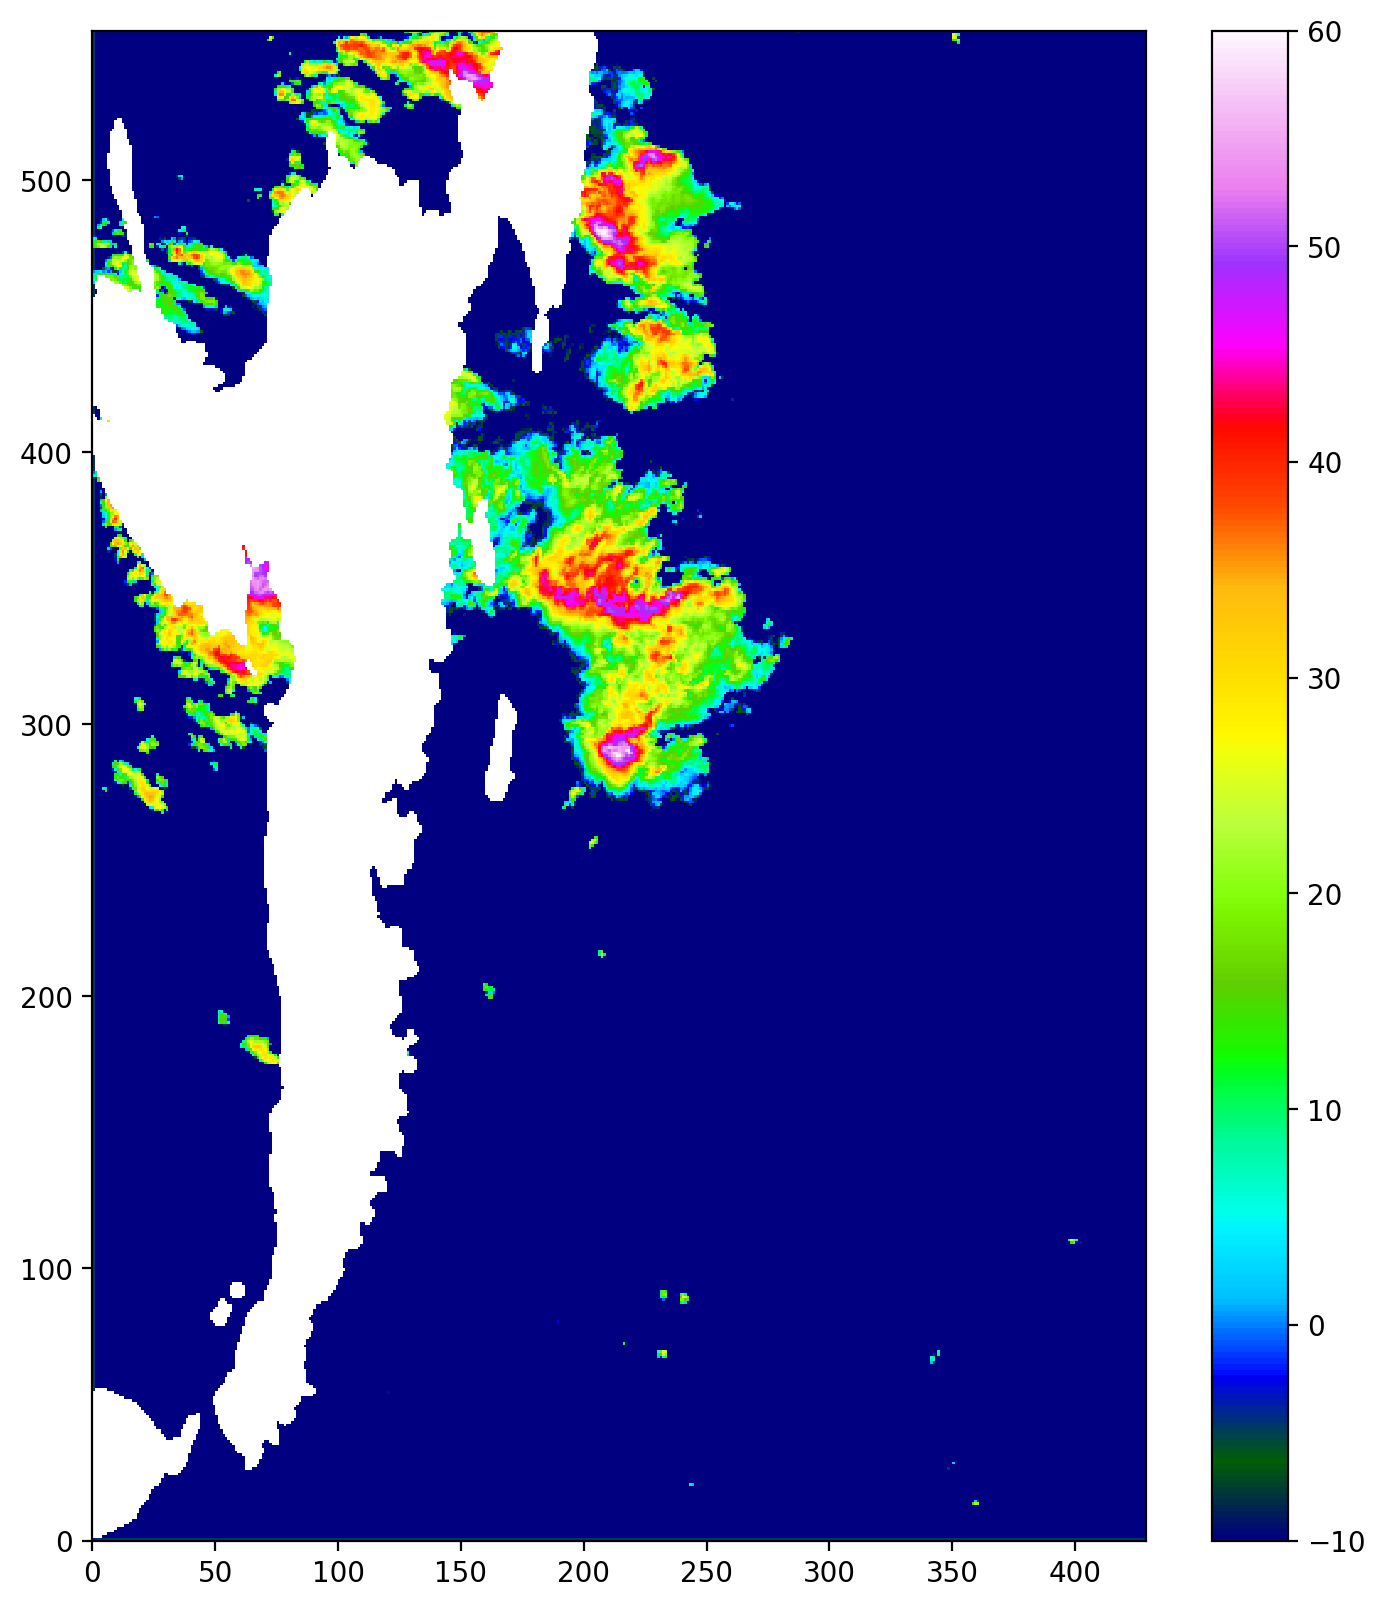

In [29]:
fig = plt.figure(figsize=[8.5,10], dpi=200)
plt.pcolormesh(refl_conv[::5,::5], vmin=-10, vmax=60, cmap='gist_ncar')
plt.colorbar()

(array([1.48303897e-02, 1.61920043e-02, 1.74290808e-02, 1.79210056e-02,
        1.96188725e-02, 2.13873108e-02, 2.23296477e-02, 2.31266903e-02,
        2.53891291e-02, 2.70413321e-02, 2.71409624e-02, 2.70683153e-02,
        2.89592159e-02, 2.98102250e-02, 2.97915443e-02, 3.01091160e-02,
        2.98932503e-02, 3.00613764e-02, 3.10722092e-02, 3.03457380e-02,
        2.85503164e-02, 2.76889292e-02, 2.78612066e-02, 2.81933077e-02,
        2.77761057e-02, 2.85005013e-02, 2.63605248e-02, 2.52583643e-02,
        2.38324052e-02, 2.19975466e-02, 2.12295628e-02, 1.86350230e-02,
        1.73377530e-02, 1.66361895e-02, 1.59387772e-02, 1.62127606e-02,
        1.54759113e-02, 1.41309018e-02, 1.31989431e-02, 1.14201266e-02,
        9.85510014e-03, 8.98125912e-03, 7.96835077e-03, 7.41623269e-03,
        6.64617326e-03, 5.65194559e-03, 4.66394482e-03, 4.13050743e-03,
        3.70707853e-03, 3.22138067e-03, 2.69417017e-03, 2.23130426e-03,
        1.98430407e-03, 1.73107698e-03, 1.34708509e-03, 6.828828

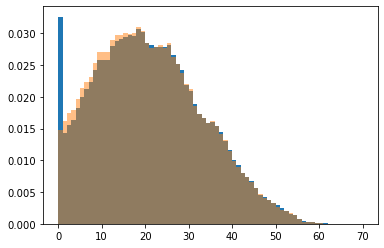

In [31]:
zbins = np.arange(0, 70.1, 1)
# plt.hist(REFL_10CM_MAX.data.ravel(), bins=zbins, density=True)
plt.hist(REFL_10CM.sel(HAMSL=1000).data.ravel(), bins=zbins, density=True)
plt.hist(refl_conv.ravel(), bins=zbins, density=True, alpha=0.5)
# plt.hist(refl_conv[::5,::5].ravel(), bins=zbins, density=True, alpha=0.5)

In [12]:
refl_conv[::5,::5].shape

(555, 429)

In [15]:
# diff = (REFL_10CM_MAX.data - refl_conv)

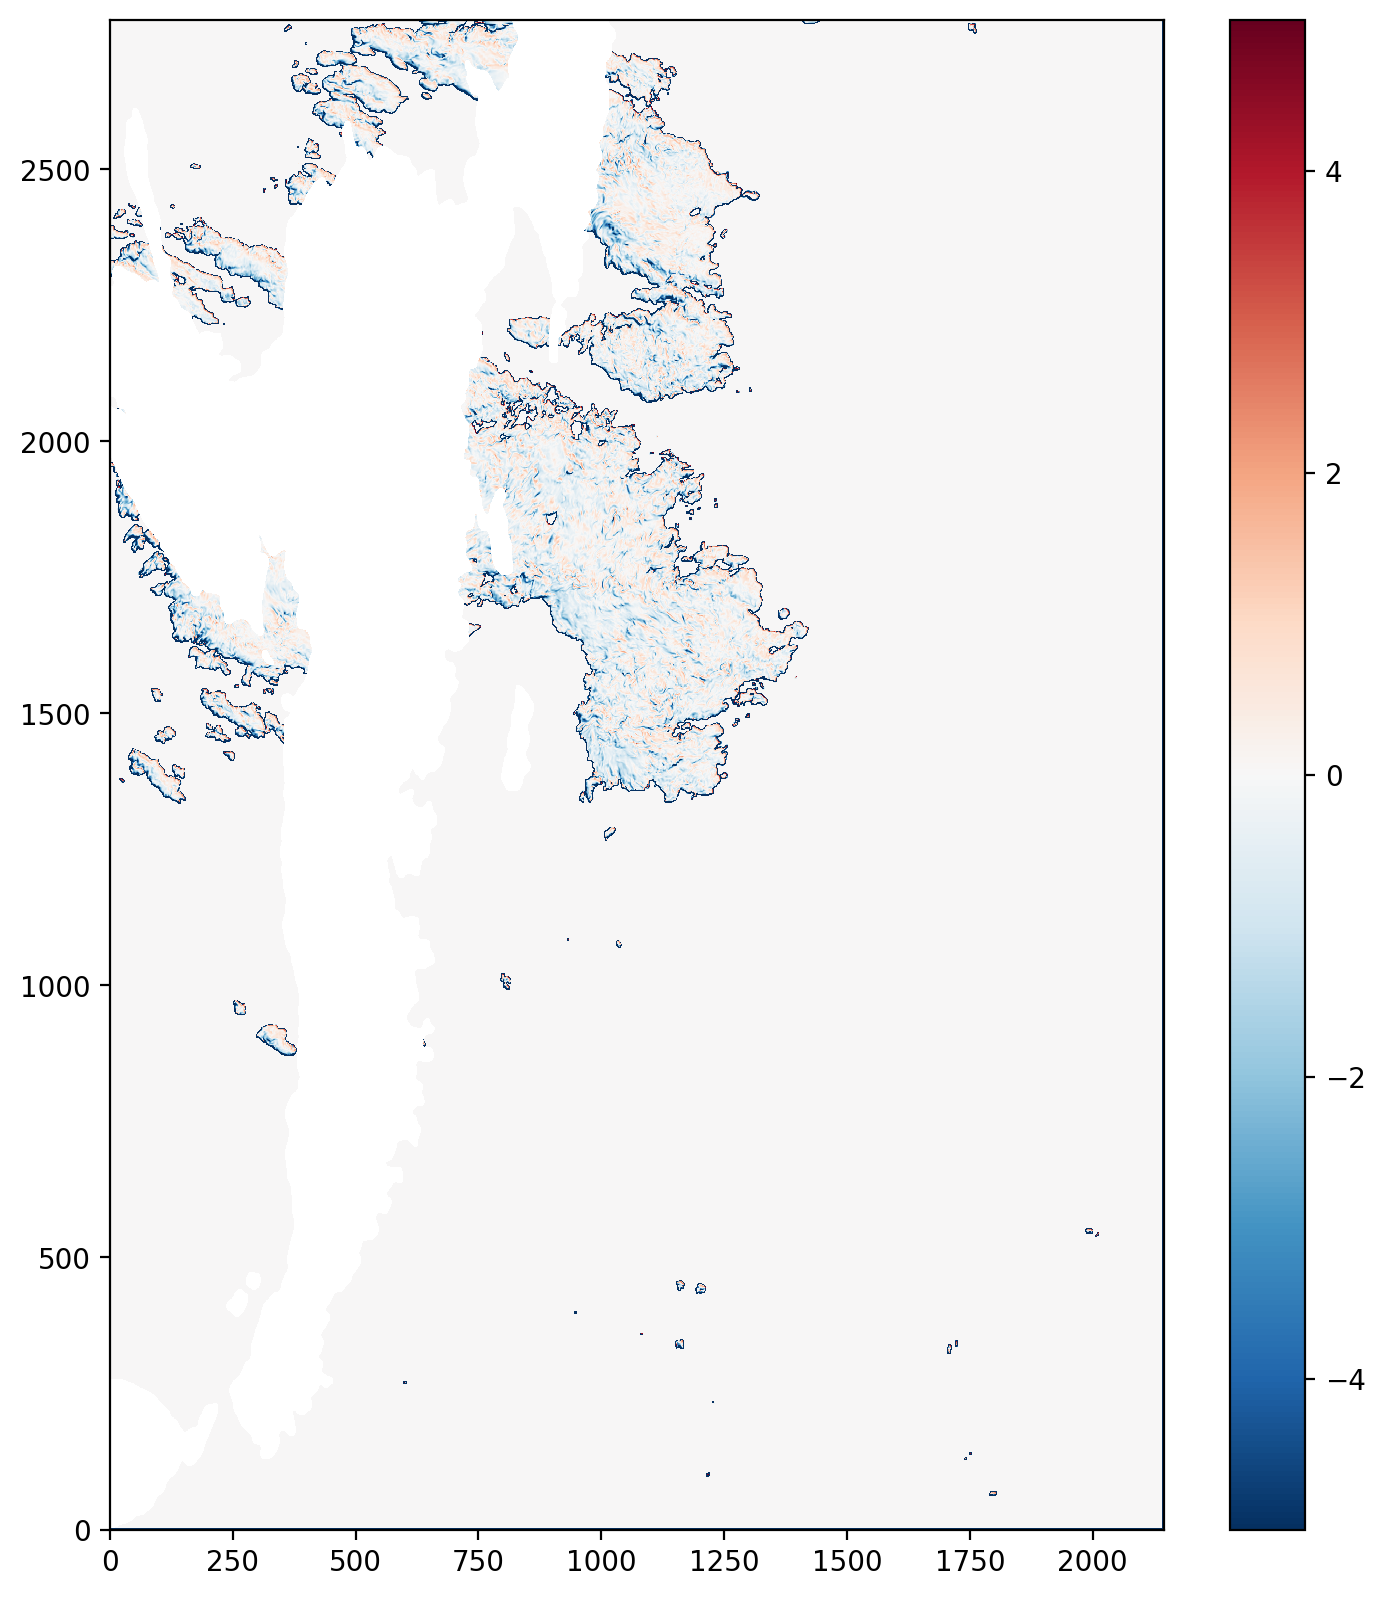

In [32]:
fig = plt.figure(figsize=[8.5,10], dpi=200)
diff = (REFL_10CM.sel(HAMSL=1000).data - refl_conv)
plt.pcolormesh(diff, vmin=-5, vmax=5, cmap='RdBu_r')
plt.colorbar()